In [14]:
import pandas as pd
log_path = r'prueba1.csv'
df_log = pd.read_csv(log_path, dtype=str)
df_log

,time,ts,utm_x,utm_y,z,utm_zone_n,utm_zone_l,heading,inx_x,inx_y,inx_z,inx_yaw,raw
0,1784665080807,CEED2F0000000000,A2D0AA01,0781A033,662D0000,12000000,4C000000,6D730000,58000000,00000000,00000000,F3FFFFFF,CEED2F0000000000A2D0AA010781A033662D0000120000...
1,1784665080807,32EE2F0000000000,BCD0AA01,0781A033,662D0000,12000000,4C000000,6D730000,71000000,00000000,FFFFFFFF,F3FFFFFF,32EE2F0000000000BCD0AA010781A033662D0000120000...
2,1784665080807,96EE2F0000000000,D6D0AA01,0781A033,662D0000,12000000,4C000000,6D730000,8B000000,00000000,FFFFFFFF,F3FFFFFF,96EE2F0000000000D6D0AA010781A033662D0000120000...
3,1784665080807,FAEE2F0000000000,F0D0AA01,0781A033,662D0000,12000000,4C000000,6D730000,A5000000,00000000,FEFFFFFF,F3FFFFFF,FAEE2F0000000000F0D0AA010781A033662D0000120000...
4,1784665080807,5EEF2F0000000000,0AD1AA01,0781A033,662D0000,12000000,4C000000,6D730000,BF000000,00000000,FEFFFFFF,F3FFFFFF,5EEF2F00000000000AD1AA010781A033662D0000120000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1632,1784665245807,9973320000000000,D373A901,3128A133,662D0000,12000000,4C000000,F3720000,60850100,BBFFFFFF,4FF9FFFF,79FFFFFF,9973320000000000D373A9013128A133662D0000120000...
1633,1784665245807,FD73320000000000,8E73A901,5228A133,662D0000,12000000,4C000000,F3720000,AC850100,BBFFFFFF,4EF9FFFF,79FFFFFF,FD733200000000008E73A9015228A133662D0000120000...
1634,1784665245807,6174320000000000,4973A901,7328A133,662D0000,12000000,4C000000,F2720000,F9850100,BBFFFFFF,4CF9FFFF,78FFFFFF,61743200000000004973A9017328A133662D0000120000...
1635,1784665245807,C574320000000000,0573A901,9428A133,662D0000,12000000,4C000000,F2720000,45860100,BBFFFFFF,4BF9FFFF,78FFFFFF,C5743200000000000573A9019428A133662D0000120000...


In [15]:
# Columnas hexadecimales little-endian (excluimos 'time' que ya es decimal, y 'raw' que es la concatenación)
hex_cols = [c for c in df_log.columns if c not in ("time", "raw")]

def hex_to_int(x):
    return int.from_bytes(bytes.fromhex(x), byteorder="little", signed=True)

for column in hex_cols:
    df_log[column] = df_log[column].apply(hex_to_int)

# 'time' es epoch en ms (entero decimal), lo convertimos aparte
df_log["time"] = df_log["time"].astype("int64")

df_log

,time,ts,utm_x,utm_y,z,utm_zone_n,utm_zone_l,heading,inx_x,inx_y,inx_z,inx_yaw,raw
0,1784665080807,3141070,27971746,866156807,11622,18,76,29549,88,0,0,-13,CEED2F0000000000A2D0AA010781A033662D0000120000...
1,1784665080807,3141170,27971772,866156807,11622,18,76,29549,113,0,-1,-13,32EE2F0000000000BCD0AA010781A033662D0000120000...
2,1784665080807,3141270,27971798,866156807,11622,18,76,29549,139,0,-1,-13,96EE2F0000000000D6D0AA010781A033662D0000120000...
3,1784665080807,3141370,27971824,866156807,11622,18,76,29549,165,0,-2,-13,FAEE2F0000000000F0D0AA010781A033662D0000120000...
4,1784665080807,3141470,27971850,866156807,11622,18,76,29549,191,0,-2,-13,5EEF2F00000000000AD1AA010781A033662D0000120000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1632,1784665245807,3306393,27882451,866199601,11622,18,76,29427,99680,-69,-1713,-135,9973320000000000D373A9013128A133662D0000120000...
1633,1784665245807,3306493,27882382,866199634,11622,18,76,29427,99756,-69,-1714,-135,FD733200000000008E73A9015228A133662D0000120000...
1634,1784665245807,3306593,27882313,866199667,11622,18,76,29426,99833,-69,-1716,-136,61743200000000004973A9017328A133662D0000120000...
1635,1784665245807,3306693,27882245,866199700,11622,18,76,29426,99909,-69,-1717,-136,C5743200000000000573A9019428A133662D0000120000...


In [16]:
# Escalado a unidades reales (confirmado contra ControlBox_prueba1.db y por consistencia interna)
# Todos los enteros vienen en centesimas (valor x100): posicion/altura en cm, angulos en centesimas de grado.
#   z=11622 -> 116.22 (IBeacon.altitude), heading=29549 -> 295.49 (HeadingBeacon=295.5)
#   inx_x=99985 -> 999.85 m ~= distancia UTM recorrida (~993 m)
#   inx_yaw=-136 -> -1.36 deg ~= variacion de heading (-1.23 deg)

df_log["utm_x"]   = df_log["utm_x"] / 100.0        # m (UTM Este)
df_log["utm_y"]   = df_log["utm_y"] / 100.0        # m (UTM Norte)
df_log["z"]       = df_log["z"] / 100.0            # m (altura)
df_log["heading"] = df_log["heading"] / 100.0      # grados

df_log["utm_zone_l"] = df_log["utm_zone_l"].apply(chr)   # 76 -> 'L'
# utm_zone_n queda como entero (18)

# Offsets INS relativos a la baliza (mismo factor: centesimas)
df_log["inx_x"]   = df_log["inx_x"] / 100.0        # m
df_log["inx_y"]   = df_log["inx_y"] / 100.0        # m
df_log["inx_z"]   = df_log["inx_z"] / 100.0        # m
df_log["inx_yaw"] = df_log["inx_yaw"] / 100.0      # grados

# time a datetime (epoch ms)
df_log["time"] = pd.to_datetime(df_log["time"], unit="ms")

df_log

,time,ts,utm_x,utm_y,z,utm_zone_n,utm_zone_l,heading,inx_x,inx_y,inx_z,inx_yaw,raw
0,2026-07-21 20:18:00.807,3141070,279717.46,8661568.07,116.22,18,L,295.49,0.88,0.00,0.00,-0.13,CEED2F0000000000A2D0AA010781A033662D0000120000...
1,2026-07-21 20:18:00.807,3141170,279717.72,8661568.07,116.22,18,L,295.49,1.13,0.00,-0.01,-0.13,32EE2F0000000000BCD0AA010781A033662D0000120000...
2,2026-07-21 20:18:00.807,3141270,279717.98,8661568.07,116.22,18,L,295.49,1.39,0.00,-0.01,-0.13,96EE2F0000000000D6D0AA010781A033662D0000120000...
3,2026-07-21 20:18:00.807,3141370,279718.24,8661568.07,116.22,18,L,295.49,1.65,0.00,-0.02,-0.13,FAEE2F0000000000F0D0AA010781A033662D0000120000...
4,2026-07-21 20:18:00.807,3141470,279718.50,8661568.07,116.22,18,L,295.49,1.91,0.00,-0.02,-0.13,5EEF2F00000000000AD1AA010781A033662D0000120000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1632,2026-07-21 20:20:45.807,3306393,278824.51,8661996.01,116.22,18,L,294.27,996.80,-0.69,-17.13,-1.35,9973320000000000D373A9013128A133662D0000120000...
1633,2026-07-21 20:20:45.807,3306493,278823.82,8661996.34,116.22,18,L,294.27,997.56,-0.69,-17.14,-1.35,FD733200000000008E73A9015228A133662D0000120000...
1634,2026-07-21 20:20:45.807,3306593,278823.13,8661996.67,116.22,18,L,294.26,998.33,-0.69,-17.16,-1.36,61743200000000004973A9017328A133662D0000120000...
1635,2026-07-21 20:20:45.807,3306693,278822.45,8661997.00,116.22,18,L,294.26,999.09,-0.69,-17.17,-1.36,C5743200000000000573A9019428A133662D0000120000...


In [17]:
def plot_window(df, ts_array="t_rel", data_array=None):# plt.figure(figsize=(10, 5))
    plt.plot(df[ts_array], df[data_array], label=data_array)
    # plt.xlabel("Hora")
    # plt.ylabel("Velocidad [km/h]")
    # plt.title("Velocidad vehicular OBD-II sincronizada")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

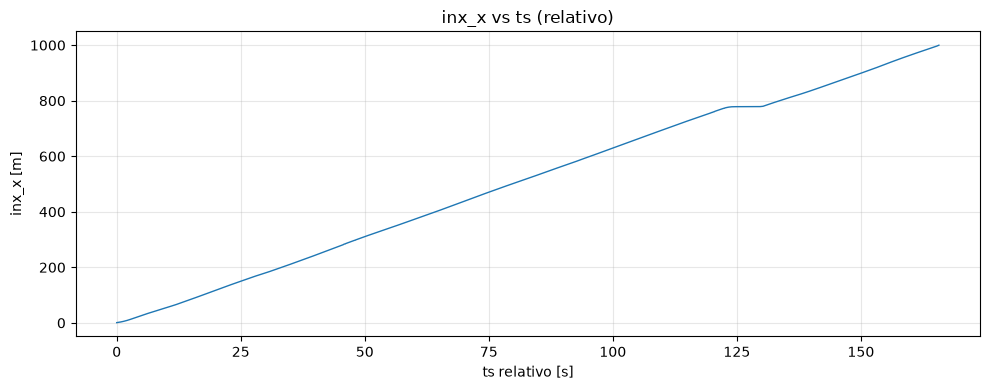

In [18]:
import matplotlib.pyplot as plt

# ts relativo en segundos (1 unidad de ts ~ 1 ms)
t_rel = (df_log["ts"] - df_log["ts"].iloc[0]) / 1000.0

# 1) inx_x vs ts (relativo)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_rel, df_log["inx_x"], lw=1)
ax.set_xlabel("ts relativo [s]")
ax.set_ylabel("inx_x [m]")
ax.set_title("inx_x vs ts (relativo)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

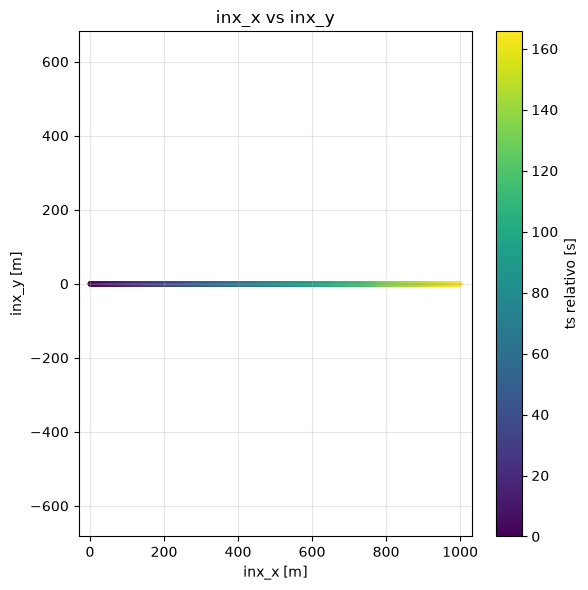

In [19]:
# 2) inx_x vs inx_y (trayectoria en el plano local del INS)
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(df_log["inx_x"], df_log["inx_y"], c=t_rel, cmap="viridis", s=8)
ax.plot(df_log["inx_x"], df_log["inx_y"], lw=0.5, color="gray", alpha=0.5)
ax.set_xlabel("inx_x [m]")
ax.set_ylabel("inx_y [m]")
ax.set_title("inx_x vs inx_y")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax, label="ts relativo [s]")
plt.tight_layout()
plt.show()

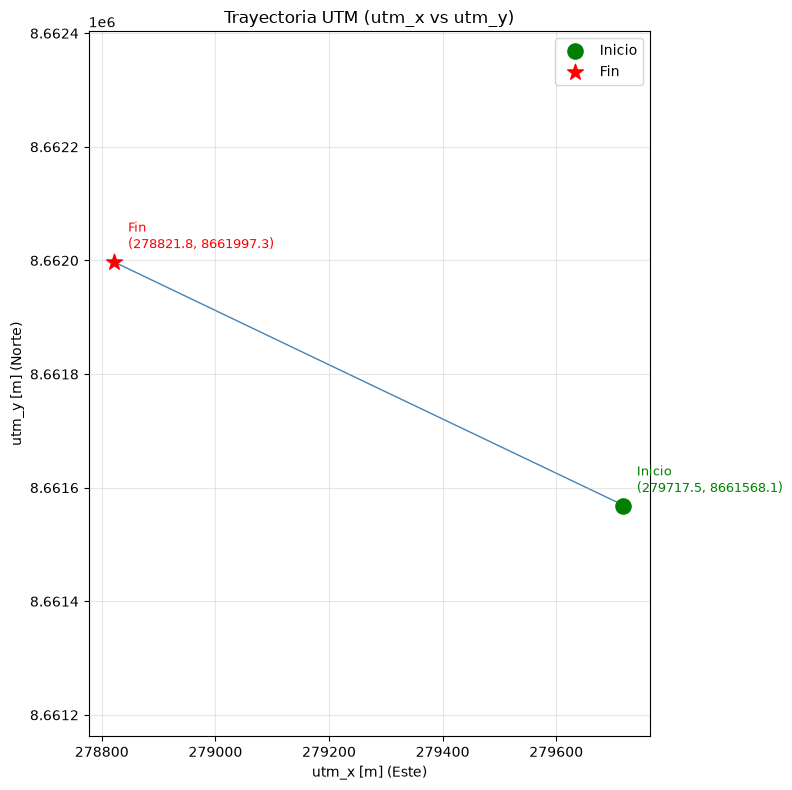

In [20]:
# Trayectoria UTM con identificadores de inicio y fin
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(df_log["utm_x"], df_log["utm_y"], lw=1, color="steelblue", zorder=1)

# Punto inicial y final
x0, y0 = df_log["utm_x"].iloc[0],  df_log["utm_y"].iloc[0]
xf, yf = df_log["utm_x"].iloc[-1], df_log["utm_y"].iloc[-1]

ax.scatter(x0, y0, color="green", s=120, marker="o", zorder=3, label="Inicio")
ax.scatter(xf, yf, color="red",   s=140, marker="*", zorder=3, label="Fin")

ax.annotate(f"Inicio\n({x0:.1f}, {y0:.1f})", (x0, y0),
            textcoords="offset points", xytext=(10, 10), color="green", fontsize=9)
ax.annotate(f"Fin\n({xf:.1f}, {yf:.1f})", (xf, yf),
            textcoords="offset points", xytext=(10, 10), color="red", fontsize=9)

ax.set_xlabel("utm_x [m] (Este)")
ax.set_ylabel("utm_y [m] (Norte)")
ax.set_title("Trayectoria UTM (utm_x vs utm_y)")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
import numpy as np
np.sqrt((278821.8 - 279717.5) **2 + (8661997.3 - 8661568.1)**2)

np.float64(993.2225984143636)

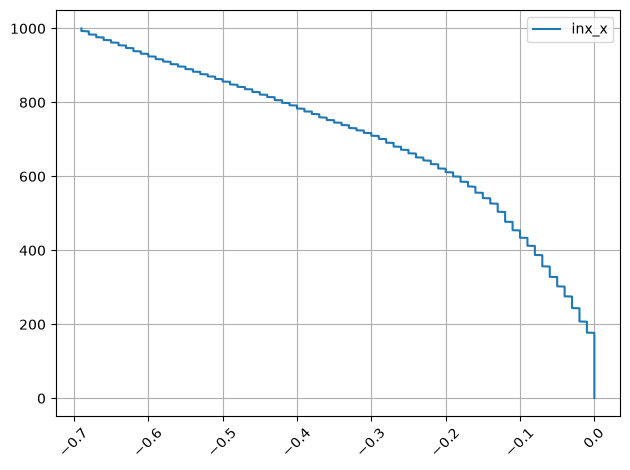

In [21]:
plot_window(df_log, ts_array="inx_y", data_array="inx_x")